# Notebook 3: Model inference and evaluation

## 1. Introduction

In this notebook, we will load a pretrained U-Net model and use it to segment CT images.

The model was trained in the previous workflow using paired CT images and binary masks. The training data included augmented simulated data and augmented real CT data. In this notebook, we focus on the practical deployment step: taking a trained model, applying it to CT images, and inspecting the predicted segmentation masks.

This is the main live notebook for the workshop. Rather than training a model during the session, we will download a pretrained model using `pooch`, load it with TensorFlow/Keras, and run inference on held-out real CT data.

We will cover:

- downloading a pretrained model from Google Cloud Storage;
- loading the model in TensorFlow/Keras;
- loading and preprocessing CT images;
- running model inference;
- visualising predicted masks as overlays;
- comparing predictions with available ground-truth masks;
- calculating simple segmentation metrics such as Dice and IoU.

The aim is to understand how a trained segmentation model can be used on CT data, and how to perform basic checks on the model output.

## 2. Imports and paths

We start by importing the libraries needed for model inference and basic evaluation.

This notebook does not need to import `segmentation_models`, because the trained model is loaded with `compile=False`. This means we do not need to provide the original training loss or metric objects when loading the model.

The notebook also defines the project paths used to find the real test data and to store the downloaded pretrained model.

### 2.1 Import libraries

In [16]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tifffile import imread
from skimage.transform import resize

import tensorflow as tf
import pooch

import utils

# Plot settings
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"

# Reproducibility
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

### 2.3 Locate the project directory

The notebook may be run from different working directories depending on how Jupyter is launched. The helper function below searches upwards from the current location until it finds the repository root.

In [2]:
def find_project_root(start_path=Path.cwd()):
    """Find the repository root from the current notebook location."""
    start_path = Path(start_path).resolve()

    for path in [start_path, *start_path.parents]:
        if (
            (path / "environment.yml").exists()
            and (path / "notebooks").exists()
            and (path / "data").exists()
        ):
            return path

    raise FileNotFoundError("Could not find the project root.")

PROJECT_DIR = find_project_root()

### 2.4 Define data and model paths

The real test data prepared in Notebook 1 are stored under:

```text
data/afternoon/augmented_real_data/test/
├── CT_data/
└── Labels/

In [3]:
DATA_DIR = PROJECT_DIR / "data" / "afternoon"

AUG_SIM_DATA_DIR = DATA_DIR / "augmented_simulated_data"
AUG_REAL_DATA_DIR = DATA_DIR / "augmented_real_data"

AUG_SIM_CT_DIR = AUG_SIM_DATA_DIR / "CT_data"
AUG_SIM_LABEL_DIR = AUG_SIM_DATA_DIR / "Labels"

REAL_TRAIN_CT_DIR = AUG_REAL_DATA_DIR / "train" / "CT_data"
REAL_TRAIN_LABEL_DIR = AUG_REAL_DATA_DIR / "train" / "Labels"

REAL_TEST_CT_DIR = AUG_REAL_DATA_DIR / "test" / "CT_data"
REAL_TEST_LABEL_DIR = AUG_REAL_DATA_DIR / "test" / "Labels"

MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory:    {DATA_DIR}")
print(f"Model directory:   {MODEL_DIR}")

Project directory: /home/ucecmjo/Data/gVXR-training-dXCT2026
Data directory:    /home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon
Model directory:   /home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/models


## 3. Download the pretrained model

In this section, we download the pretrained U-Net model used for the live inference exercise.

The model is stored in a public Google Cloud Storage bucket and is downloaded using `pooch`. Using `pooch` makes the notebook more reproducible because it checks that the downloaded file matches the expected SHA256 hash.

If the file already exists locally and the hash matches, `pooch` will reuse the cached copy rather than downloading it again.

### 3.1 Define the model URL and hash

The model URL points to the public `.keras` file in Google Cloud Storage.

The SHA256 hash is used to verify that the downloaded model is exactly the expected file.

In [4]:
model_path = Path(f"{MODEL_DIR}/unet_resnet34_binary_ct_segmentation.keras")

sha256 = hashlib.sha256(model_path.read_bytes()).hexdigest()
print(f"sha256:{sha256}")

sha256:9305b5497287e55a08757f57b83eda3b27f6abd979fc8d1c0135694d9bf4d63e


### 3.2 Download the model with `pooch`

The model is downloaded into the local `models/` directory so that it can be loaded by TensorFlow/Keras in the next step.

In [7]:
MODEL_URL = "https://storage.googleapis.com/enkitek-oss-assets-1768310361/models/unet_resnet34_binary_ct_segmentation.keras"
MODEL_HASH = "sha256:9305b5497287e55a08757f57b83eda3b27f6abd979fc8d1c0135694d9bf4d63e"

model_path = pooch.retrieve(
    url=MODEL_URL,
    known_hash=MODEL_HASH,
    fname="unet_resnet34_binary_ct_segmentation.keras",
    path=Path("models"),
)

print(model_path)

/home/ucecmjo/Data/gVXR-training-dXCT2026/notebooks/afternoon/models/unet_resnet34_binary_ct_segmentation.keras


## 4. Run inference on the reserved test data

We will now run a brief test on the reserved real test data prepared in Notebook 1.

The aim is to check that the pretrained model can:

- load successfully;
- preprocess real CT images;
- generate segmentation masks;
- compare predictions with the available ground-truth masks;
- report simple Dice and IoU scores.

This is a compact evaluation for the workshop rather than a full model validation study.

In [8]:
model = tf.keras.models.load_model(model_path, compile=False)

print("Model loaded.")

I0000 00:00:1781088902.610324  383715 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1119 MB memory:  -> device: 0, name: NVIDIA RTX 4000 Ada Generation, pci bus id: 0000:ac:00.0, compute capability: 8.9
I0000 00:00:1781088902.611846  383715 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 18149 MB memory:  -> device: 1, name: NVIDIA RTX 4000 Ada Generation, pci bus id: 0000:ca:00.0, compute capability: 8.9


Model loaded.


In [9]:
def build_test_pairs(ct_dir, label_dir):
    """Build image-mask pairs from the reserved real test data."""
    rows = []

    for ct_path in sorted(ct_dir.glob("CT-*.tiff")):
        key = ct_path.stem.removeprefix("CT-")
        label_path = label_dir / f"labels-{key}.tiff"

        rows.append(
            {
                "key": key,
                "ct_path": ct_path,
                "label_path": label_path,
                "label_exists": label_path.exists(),
            }
        )

    pairs = pd.DataFrame(rows)

    missing = pairs.loc[~pairs["label_exists"]]
    if len(missing) > 0:
        display(missing)
        raise FileNotFoundError("Some test images do not have matching labels.")

    return pairs.drop(columns="label_exists")

In [10]:
test_pairs = build_test_pairs(
    ct_dir=REAL_TEST_CT_DIR,
    label_dir=REAL_TEST_LABEL_DIR,
)

print(f"Reserved test pairs: {len(test_pairs)}")
test_pairs.head()

Reserved test pairs: 99


,key,ct_path,label_path
0,1_test_aug_000,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...
1,1_test_aug_001,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...
2,1_test_aug_002,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...
3,1_test_aug_003,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...
4,1_test_aug_004,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...


In [12]:
IMAGE_SIZE = 1024
INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 1)

In [13]:
def normalise_image(image, lower=1, upper=99):
    """Percentile-normalise a CT image to the range 0–1."""
    image = image.astype(np.float32)
    vmin, vmax = np.percentile(image, [lower, upper])

    if vmax <= vmin:
        return np.zeros_like(image, dtype=np.float32)

    image = np.clip(image, vmin, vmax)
    image = (image - vmin) / (vmax - vmin)

    return image.astype(np.float32)


def load_test_pair(ct_path, label_path, image_size=IMAGE_SIZE):
    """Load and preprocess one test CT image and mask."""
    image = imread(ct_path).astype(np.float32)
    mask = imread(label_path).astype(np.uint8)

    image = normalise_image(image)
    mask = (mask > 0).astype(np.uint8)

    image = resize(
        image,
        (image_size, image_size),
        order=1,
        preserve_range=True,
        anti_aliasing=True,
    ).astype(np.float32)

    mask = resize(
        mask,
        (image_size, image_size),
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    ).astype(np.uint8)

    image = image[..., np.newaxis]
    mask = mask[..., np.newaxis]

    return image, mask

In [14]:
def dice_score(y_true, y_pred):
    """Calculate Dice score for binary masks."""
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    intersection = np.logical_and(y_true, y_pred).sum()
    denominator = y_true.sum() + y_pred.sum()

    if denominator == 0:
        return 1.0

    return 2 * intersection / denominator


def iou_score(y_true, y_pred):
    """Calculate IoU score for binary masks."""
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()

    if union == 0:
        return 1.0

    return intersection / union

In [17]:
results = []

for _, row in test_pairs.iterrows():
    image, mask = load_test_pair(row["ct_path"], row["label_path"])

    prediction = model.predict(image[np.newaxis, ...], verbose=0)
    probability = prediction[0, ..., 0]
    predicted_mask = probability > 0.5

    dice = dice_score(mask[..., 0], predicted_mask)
    iou = iou_score(mask[..., 0], predicted_mask)

    results.append(
        {
            "key": row["key"],
            "dice": dice,
            "iou": iou,
        }
    )

results_df = pd.DataFrame(results)

results_df

I0000 00:00:1781089200.051167  388364 service.cc:152] XLA service 0x7f58d0002a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781089200.051209  388364 service.cc:160]   StreamExecutor device (0): NVIDIA RTX 4000 Ada Generation, Compute Capability 8.9
I0000 00:00:1781089200.051213  388364 service.cc:160]   StreamExecutor device (1): NVIDIA RTX 4000 Ada Generation, Compute Capability 8.9
2026-06-10 12:00:00.127125: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781089200.667106  388364 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-06-10 12:00:01.462299: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.14GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if m

,key,dice,iou
0,1_test_aug_000,0.898286,0.815353
1,1_test_aug_001,0.888990,0.800163
2,1_test_aug_002,0.893752,0.807913
3,1_test_aug_003,0.894596,0.809293
4,1_test_aug_004,0.891246,0.803827
...,...,...,...
94,6_test_aug_028,0.879246,0.784512
95,6_test_aug_029,0.878518,0.783354
96,6_test_aug_030,0.879627,0.785120
97,6_test_aug_031,0.873150,0.774859


In [18]:
print(f"Mean Dice: {results_df['dice'].mean():.3f}")
print(f"Mean IoU:  {results_df['iou'].mean():.3f}")

Mean Dice: 0.883
Mean IoU:  0.791


In [19]:
example = test_pairs.iloc[0]

image, mask = load_test_pair(example["ct_path"], example["label_path"])

prediction = model.predict(image[np.newaxis, ...], verbose=0)
probability = prediction[0, ..., 0]
predicted_mask = probability > 0.5

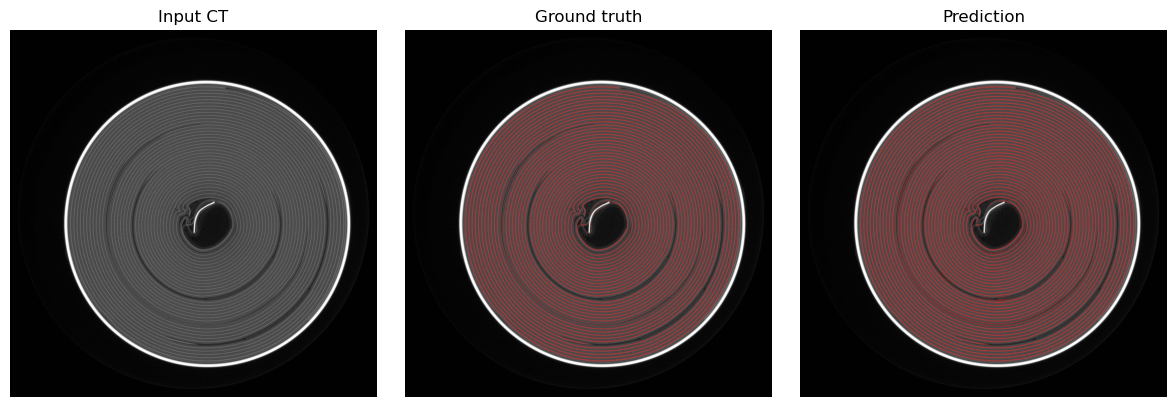

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image[..., 0], cmap="gray")
plt.title("Input CT")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(image[..., 0], cmap="gray")
plt.imshow(utils.make_red_overlay(mask[..., 0], alpha=0.35))
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image[..., 0], cmap="gray")
plt.imshow(utils.make_red_overlay(predicted_mask, alpha=0.35))
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

### Notes on interpretation

This test gives a quick indication of model behaviour on the reserved real test data. Because the real dataset is small and the test set was geometrically augmented for workshop purposes, these scores should be interpreted as a demonstration metric rather than a formal estimate of real-world model performance.

The most important checks in this notebook are that the model loads correctly, runs inference successfully, and produces masks that are visually aligned with the CT image.